<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/Aula_2_Raizes_de_fun%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Método Gráfico

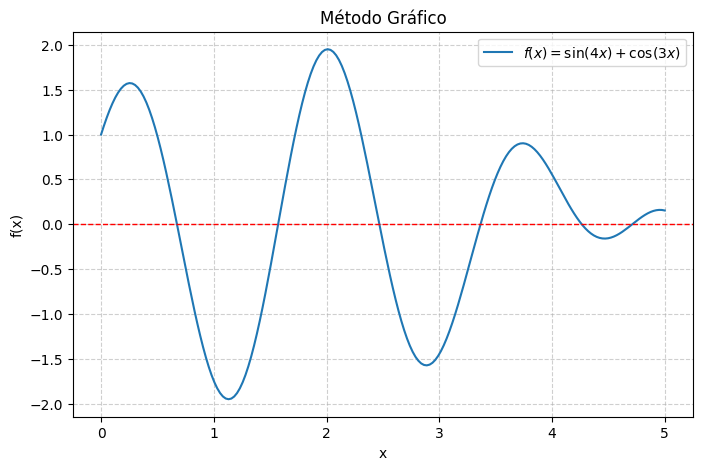

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(4*x) + np.cos(3*x)

# Definir intervalo de x
xmin, xmax = 0, 5
ns = 200
x = np.linspace(xmin, xmax, ns)
y = f(x)

# Plotar a função
plt.figure(figsize=(8,5))
plt.plot(x, y, label='$f(x) = \sin(4x) + \cos(3x)$')
plt.axhline(0, color='r', linewidth=1, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.title("Método Gráfico")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


Método da Busca Incremental

Subintervalos: [[3.25628141 3.27135678]
 [3.36180905 3.37688442]
 [3.73869347 3.75376884]
 [4.22110553 4.2361809 ]
 [4.25125628 4.26633166]
 [4.70351759 4.71859296]
 [5.15577889 5.17085427]
 [5.18592965 5.20100503]
 [5.66834171 5.68341709]]


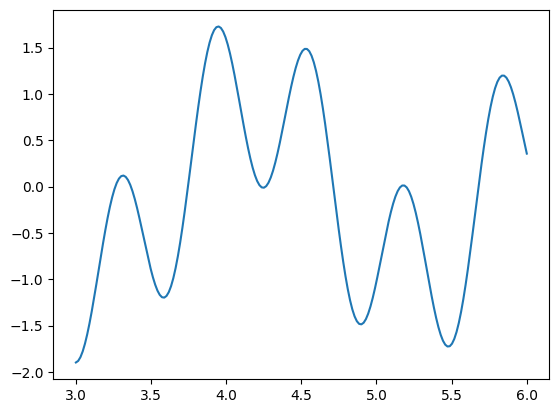

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def busca_incremental(func,xmin,xmax,ns):
  x = np.linspace(xmin,xmax,ns)
  f = func(x)
  xb = []

  for k in range(0,len(x) - 1):
    if f[k]*f[k+1] < 0:
      xb.append([x[k], x[k+1]])

  return np.array(xb)

# Exemplo
def exemplo_func(x):
  return np.sin(10*x) + np.cos(3*x)

xmin = 3
xmax = 6
ns = 200

subintervalos = busca_incremental(exemplo_func,xmin,xmax,ns)
print('Subintervalos:',subintervalos)

x = np.linspace(xmin,xmax,ns)
plt.plot(x,exemplo_func(x))

Método da Bissecção - exercício 1

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 2

#valor exato
xe = math.sqrt(2)

#extremidades do intervalo
xl = 0
xu = 2

#criterio de parada
n = 6
Eppara = (0.5 * 10**(2-n))

#pré alocar informações
Ept = 100

while Ept > Eppara:
  xr = (xl + xu)/2

  if f(xl)*f(xr) < 0:
    xu = xr
  elif f(xr)*f(xu) < 0:
    xl = xr

  Ept = abs((xe - xr)/xe)*100

print(xr)

1.4142131805419922


Método da Falsa Posição

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 2

#valor exato
xe = math.sqrt(2)

#extremidades do intervalo
xl = 0
xu = 2

#criterio de parada
n = 10
Eppara = (0.5 * 10**(2-n))

#pré alocar informações
Ept = 100

while Ept > Eppara:
  xr = xu - ((f(xu)*(xl-xu))/(f(xl)-f(xu)))

  if f(xl)*f(xr) < 0:
    xu = xr
  elif f(xr)*f(xu) < 0:
    xl = xr

  Ept = abs((xe - xr)/xe)*100

print(xr)

1.4142135623189167


Newton Raphson

In [ ]:
import numpy as np
import math

def f(x):
    return math.exp(-x) - x

def df(x):
  return -math.exp(-x) - 1

#definindo variaveis
n = 6
Eppara = 0.5*10**(2-n)

x_old = 0
Epest = 100

while Epest >= Eppara:
  x_new = x_old - ((f(x_old))/df(x_old))
  Epest = abs((x_new - x_old)/x_new)*100
  x_old = x_new

print(x_new)

0.5671432904097811


Método da Secante

In [ ]:
import numpy as np
import math

def f(x):
    return math.exp(-x) - x

#definindo variaveis
n = 6
Eppara = 0.5*10**(2-n)

x_old = 0
Ept = 100
x_old_old = 1

while Ept >= Eppara:
  x_new = x_old - f(x_old) * (x_old - x_old_old) / (f(x_old) - f(x_old_old))
  Ept = abs((x_new - x_old)/x_new)*100
  x_old_old = x_old
  x_old = x_new

print(x_new)

0.5671432904100638


Secante Modificado

In [ ]:
import math

def f(x):
    return math.exp(-x) - x

# Definindo as variáveis
n = 6
Eppara = 0.5*10**(2-n)

x_old = 1  # Valor inicial
Ept = 100
delta = 0.01  # Valor de delta

# Laço while para método da secante modificada
while Ept >= Eppara:
    x_new = x_old - (delta * x_old * f(x_old)) / (f(x_old + delta*x_old) - f(x_old))
    Ept = abs((x_new - x_old)/x_new)*100
    x_old = x_new

print(x_new)

0.5671432902726529
